In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [ ]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [ ]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [ ]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [ ]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [ ]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}
#name of kernel

In [ ]:
# Create SVM classifier
svm = SVC(random_state=42)

In [ ]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [ ]:
# Start timing
start_time = time.time()


In [ ]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [ ]:
# End timing
grid_time = time.time() - start_time

In [ ]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 23.25 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [ ]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [ ]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

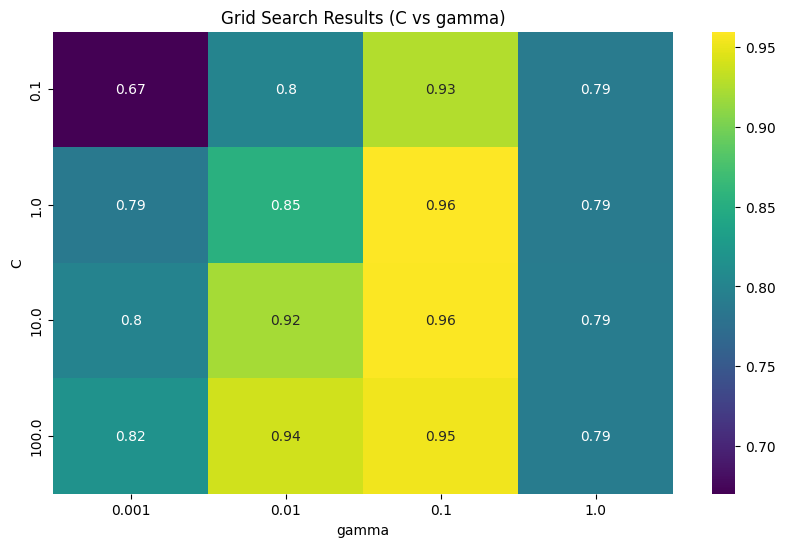

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [ ]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [ ]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [ ]:
# Start timing
start_time = time.time()

In [ ]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d321cfb2b40>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d321ccbc560>,
                                        'kernel': ['rbf', 'poly']},
                   random_state=42, return_train_score=True,
                   scoring='accuracy')

In [ ]:
# End timing
random_time = time.time() - start_time

In [ ]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 6.57 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [ ]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [ ]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456           23.248821
1  Random Search       0.971429       0.964912            6.573000


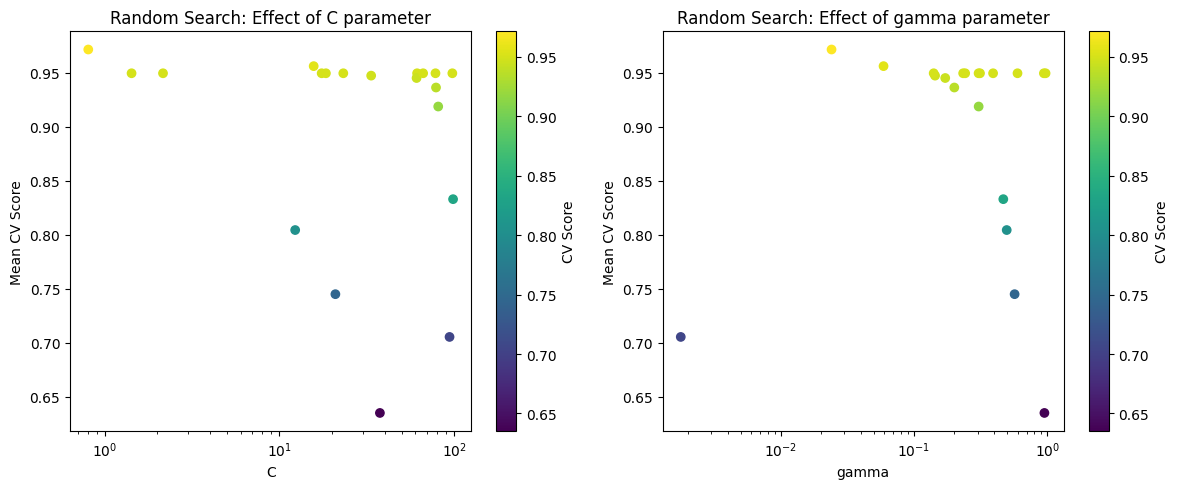

In [ ]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [ ]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.4 MB/s eta 0:00:00


In [ ]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [ ]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [ ]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [ ]:
# Start timing
start_time = time.time()

In [ ]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

BayesSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
              random_state=42, return_train_score=True, scoring='accuracy',
              search_spaces={'C': Real(low=0.1, high=100, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('rbf', 'poly'), prior=None)})

In [ ]:
# End timing
bayes_time = time.time() - start_time

In [ ]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 24.10 seconds
Best parameters: OrderedDict({'C': 47.479208101330435, 'gamma': 0.01504196942704713, 'kernel': 'rbf'})
Best cross-validation score: 0.9626


In [ ]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [ ]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456           23.248821
1          Random Search       0.971429       0.964912            6.573000
2  Bayesian Optimization       0.962637       0.956140           24.096732


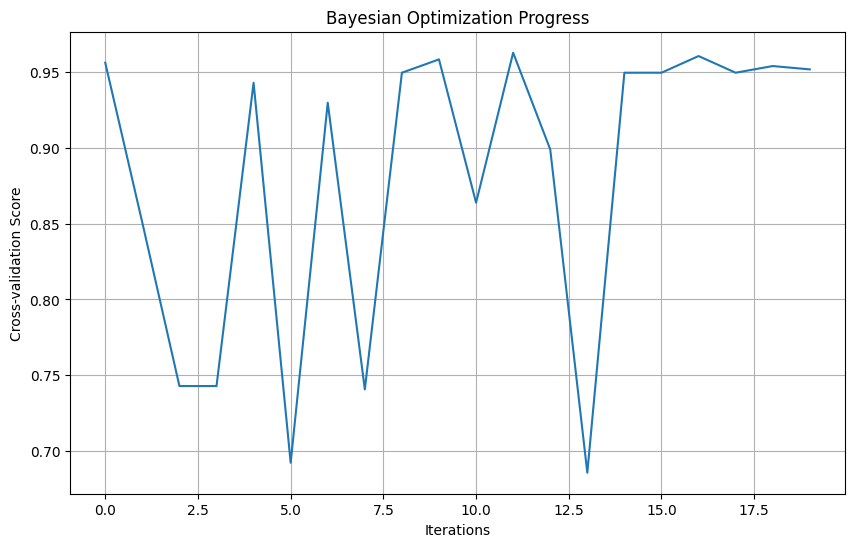

In [ ]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [ ]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [ ]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [ ]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [ ]:
# Start timing
start_time = time.time()

In [ ]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d321937e3f0>,
                                        'regressor__max_features': ['auto',
                                                                    'sqrt',
                                                                    'log2',
                                                                    None],
                                        'regressor__min_sample...._distn_infrastructure.rv_discrete_frozen object at 0x7d32193328d0>,
                                        'regressor__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d32193301d0>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d32193307a0>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [ ]:
# End timing
rf_random_time = time.time() - start_time

In [ ]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 82.27 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [ ]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [ ]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

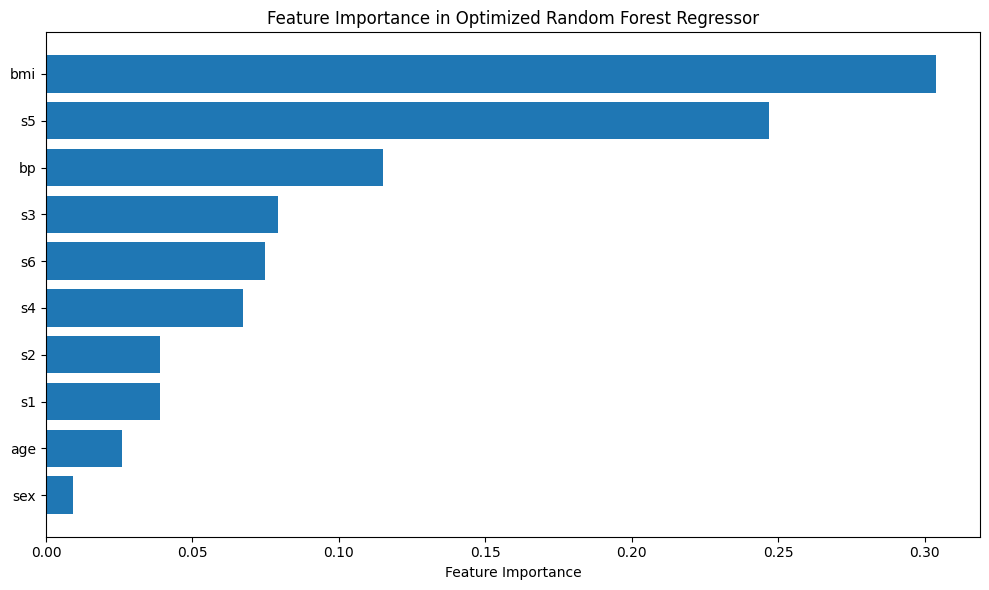

In [ ]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [ ]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [ ]:
from sklearn.model_selection import learning_curve


In [ ]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

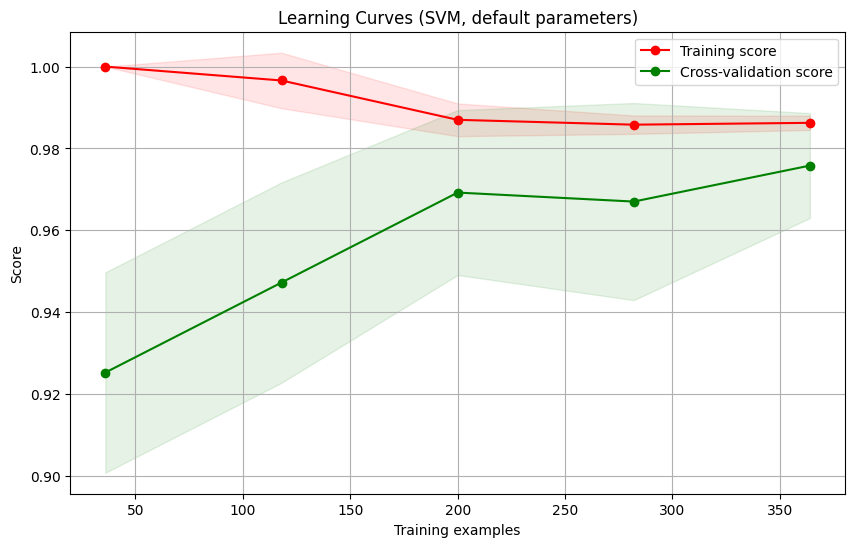

In [ ]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

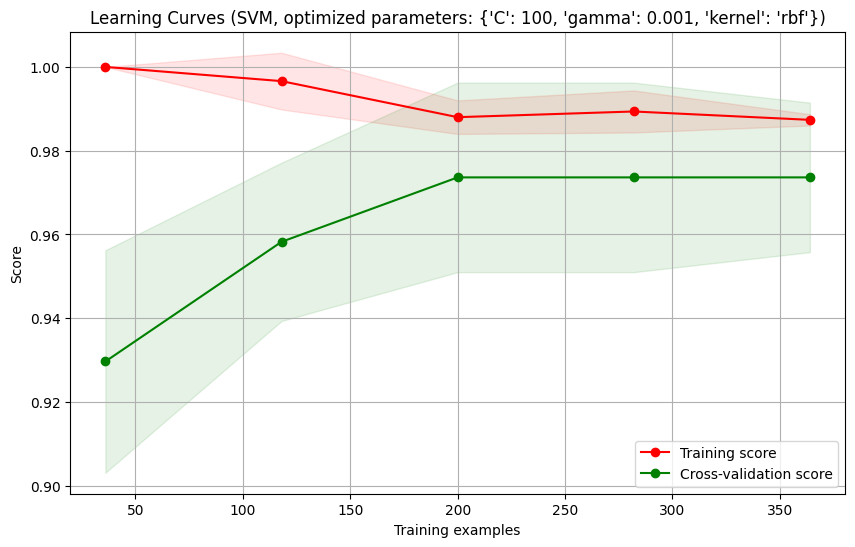

In [ ]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [ ]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

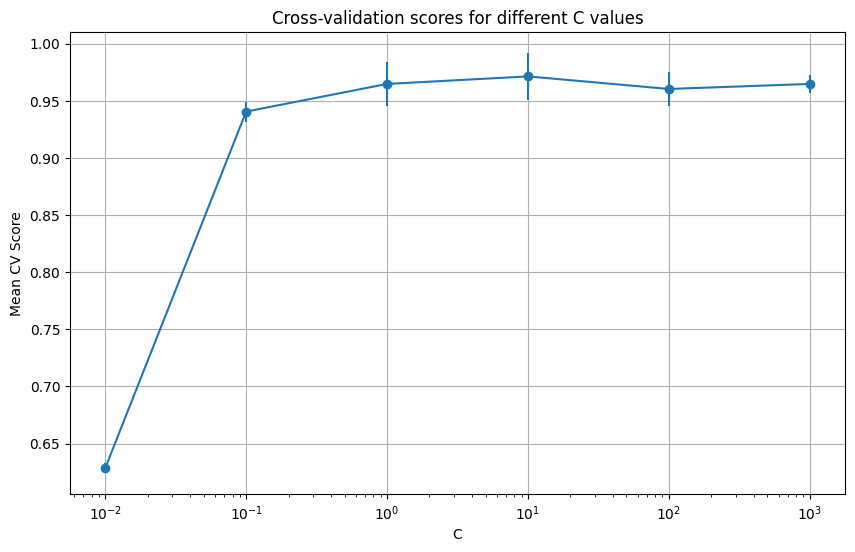

In [ ]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

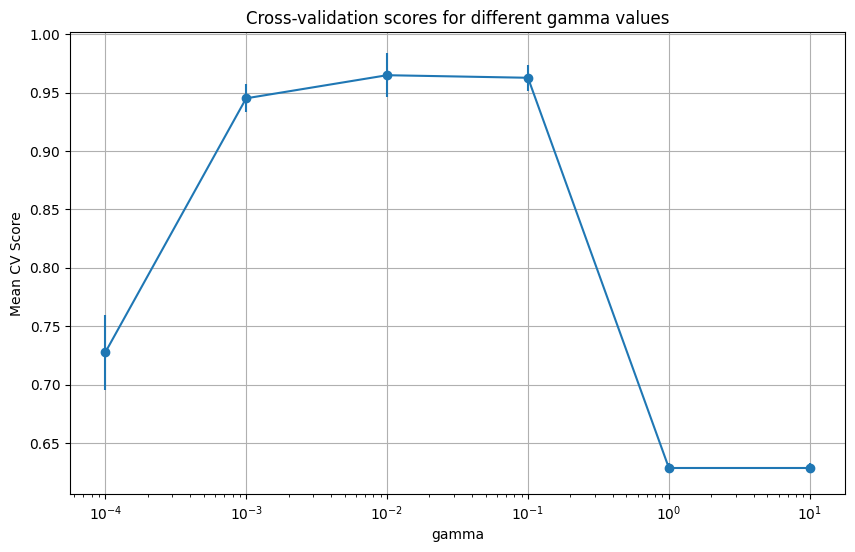

In [ ]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [ ]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [ ]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [ ]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [ ]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [ ]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [ ]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d321939b2f0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d32192eee70>,
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy')

In [ ]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [ ]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [ ]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [ ]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [ ]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456           23.248821
1          Random Search       0.971429       0.964912            6.573000
2  Bayesian Optimization       0.962637       0.956140           24.096732
3      Combined Approach       0.978022       0.982456                 NaN


/tmp/ipykernel_442/3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [ ]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

SVC(C=47.479208101330435, gamma=0.01504196942704713, probability=True,
    random_state=42)

In [ ]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [ ]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

RandomForestRegressor(random_state=42)

In [ ]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

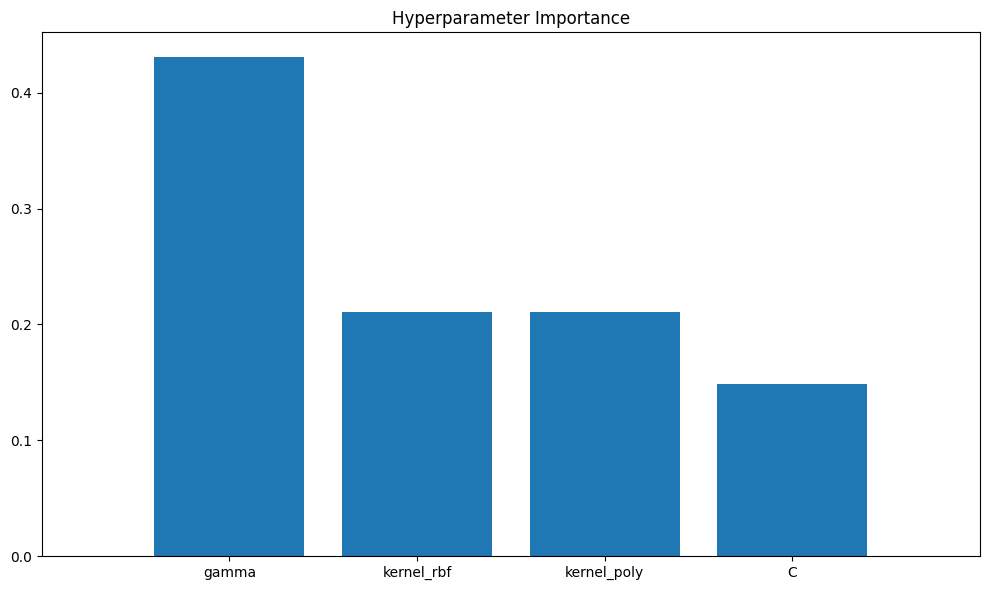

In [ ]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [ ]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

/tmp/ipykernel_442/149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


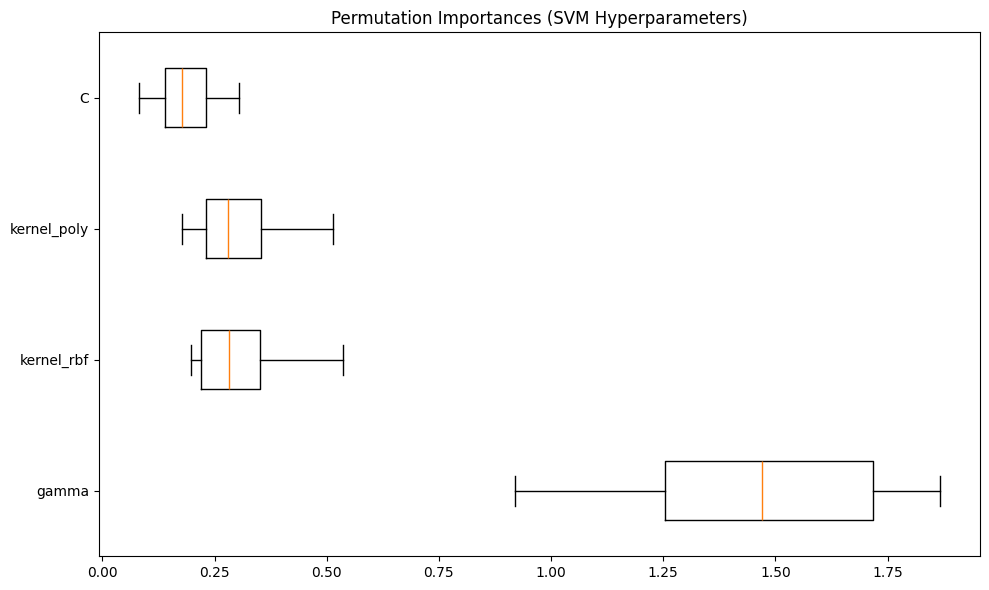

In [ ]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [ ]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [ ]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 )
# TODO: Standardize the features using StandardScaler
# YOUR CODE HERE
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Ridge
RMSE: 0.7205 ± 0.0103
R²: 0.6115 ± 0.0065
SVR
RMSE: 0.5931 ± 0.0106
R²: 0.7368 ± 0.0048
Random Forest
RMSE: 0.5115 ± 0.0044
R²: 0.8042 ± 0.0053
Gradient Boosting
RMSE: 0.5340 ± 0.0071
R²: 0.7866 ± 0.0032


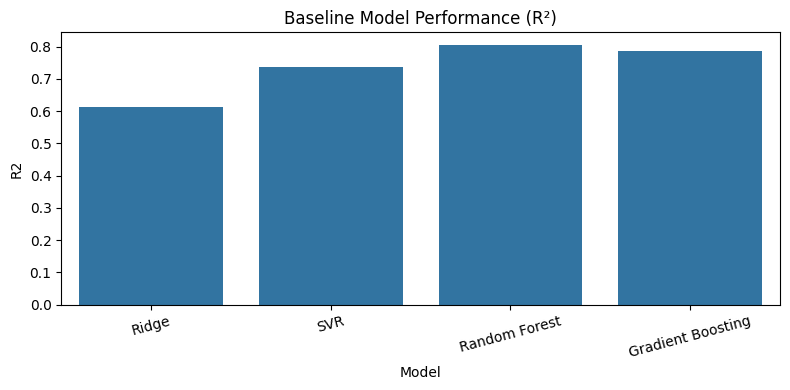

In [ ]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO: Create a dictionary of baseline models with default parameters
# Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
# YOUR CODE HERE
models = {
    "Ridge": Ridge(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),}
# TODO: Evaluate baseline models using 5-fold cross-validation
# Calculate and print mean and std of RMSE and R² for each model
# YOUR CODE HERE
results = []
for name, model in models.items():
    rmse_scores = np.sqrt(
        -cross_val_score(model,X_train,y_train,cv=5,scoring="neg_mean_squared_error",n_jobs=-1,))
    r2_scores = cross_val_score(model,X_train,y_train,cv=5,scoring="r2",n_jobs=-1,)
    results.append(
        {"Model": name,"RMSE": rmse_scores.mean(),"R2": r2_scores.mean(),})
    print(f"{name}")
    print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    print(f"R²: {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# TODO: Visualize baseline model performance with a bar plot
# YOUR CODE HERE
results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="R2")
plt.title("Baseline Model Performance (R²)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

               Model  Best Score     Time (s)  \
0              Ridge    0.611484     2.120510   
1                SVR    0.758330  1038.833610   
2      Random Forest    0.805062   808.726414   
3  Gradient Boosting    0.831167   264.573545   

                                     Best Parameters  
0                                    {'alpha': 0.01}  
1       {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}  
2  {'max_depth': 20, 'min_samples_split': 2, 'n_e...  
3  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...  


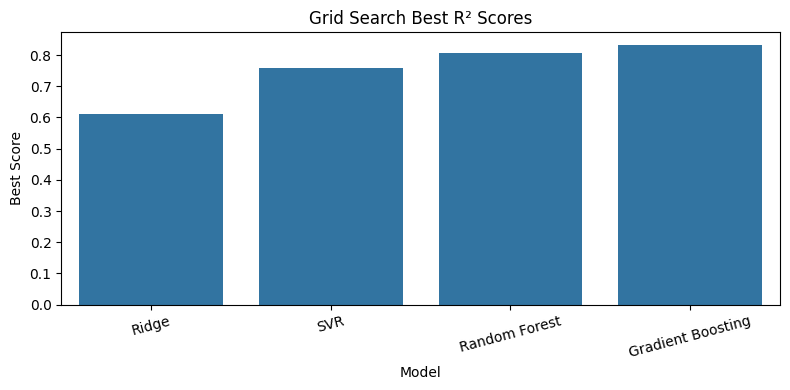

In [ ]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV

# TODO: Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
param_grids = {
    "Ridge": {"alpha": [0.01, 0.1, 1, 10, 100],},
    "SVR": {"C": [0.1, 1, 10],"gamma": ["scale", "auto"],"kernel": ["linear", "rbf"],},
    "Random Forest": {"n_estimators": [100, 200],"max_depth": [10, 20, None],"min_samples_split": [2, 5],},
    "Gradient Boosting": {"n_estimators": [100, 200],"max_depth": [3, 5],"learning_rate": [0.01, 0.1],},}

# TODO: Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def perform_grid_search(model, param_grid):
    start_time = time.time()

    grid_search = GridSearchCV(estimator=model,param_grid=param_grid,cv=5,scoring="r2",n_jobs=-1,)

    grid_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    return (grid_search.best_estimator_,grid_search.best_params_,grid_search.best_score_,elapsed_time,)
# TODO: Apply grid search to all models
# YOUR CODE HERE
grid_results = []

for name, model in models.items():
    best_model, best_params, best_score, elapsed_time = perform_grid_search(
        model, param_grids[name])

    grid_results.append({"Model": name,"Best Score": best_score,"Time (s)": elapsed_time,"Best Parameters": best_params,})
# TODO: Create a comparison table or visualization of grid search results
# YOUR CODE HERE
grid_results_df = pd.DataFrame(grid_results)

print(grid_results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=grid_results_df, x="Model", y="Best Score")
plt.title("Grid Search Best R² Scores")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

               Model  Best Score    Time (s)  \
0              Ridge    0.611094    3.117868   
1                SVR    0.757401  459.060089   
2      Random Forest    0.800391  385.109036   
3  Gradient Boosting    0.828006  278.793825   

                                     Best Parameters  
0                      {'alpha': 3.0122914019804194}  
1        {'C': 10.737555188414591, 'gamma': 'scale'}  
2  {'max_depth': 19, 'min_samples_split': 4, 'n_e...  
3  {'learning_rate': 0.13367720186661747, 'max_de...  


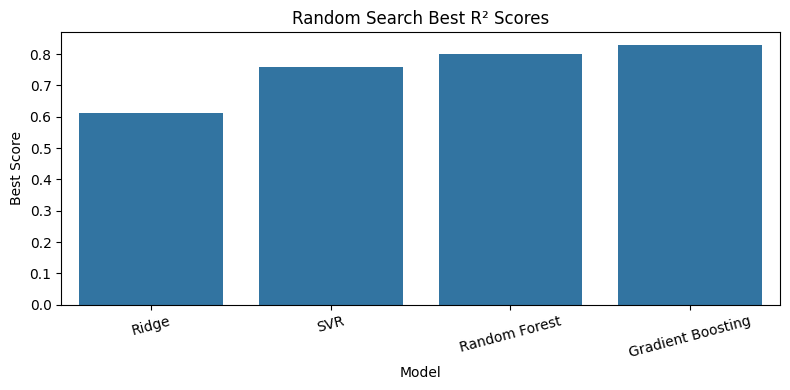

In [ ]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# TODO: Define parameter distributions for each model
# Ridge: alpha values
# SVR: C, gamma values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
param_distributions = {
    "Ridge": {"alpha": uniform(0.1, 10),},
    "SVR": {"C": uniform(1, 10),"gamma": ["scale", "auto"],},
    "Random Forest": {"n_estimators": randint(50, 150),"max_depth": randint(5, 20),"min_samples_split": randint(2, 10),},
    "Gradient Boosting": {"n_estimators": randint(50, 150),"max_depth": randint(3, 10),"learning_rate": uniform(0.01, 0.2),},}
# TODO: Create a function that performs random search for a given model and parameter distribution
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def perform_random_search(model, param_distribution):
    start_time = time.time()

    random_search = RandomizedSearchCV(estimator=model,param_distributions=param_distribution,n_iter=20,cv=3,scoring="r2",random_state=42,
        n_jobs=-1,)

    random_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    return (
        random_search.best_estimator_,random_search.best_params_,random_search.best_score_,elapsed_time,)

# TODO: Apply random search to all models with 20 iterations
# YOUR CODE HERE
random_results = []

for name, model in models.items():
    best_model, best_params, best_score, elapsed_time = perform_random_search(
        model, param_distributions[name])

    random_results.append({
            "Model": name,"Best Score": best_score,"Time (s)": elapsed_time,"Best Parameters": best_params,})
# TODO: Create a comparison table or visualization of random search results
# YOUR CODE HERE
random_results_df = pd.DataFrame(random_results)

print(random_results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=random_results_df, x="Model", y="Best Score")
plt.title("Random Search Best R² Scores")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

               Model  Best Score    Time (s)  \
0              Ridge    0.611094    8.544753   
1                SVR    0.757029  505.159461   
2      Random Forest    0.800750  496.944607   
3  Gradient Boosting    0.833519  503.239729   

                                     Best Parameters  
0                      {'alpha': 2.4596505007485354}  
1     {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}  
2  {'max_depth': 20, 'min_samples_split': 2, 'n_e...  
3  {'learning_rate': 0.13492902019385908, 'max_de...  


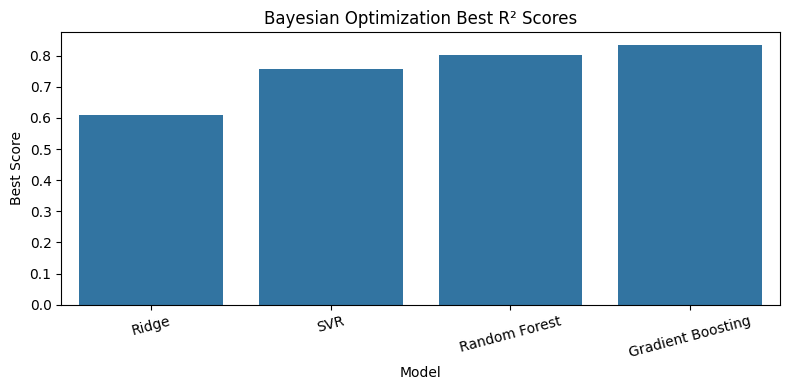

In [ ]:
# ==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================
# Install scikit-optimize if not already installed
!pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# TODO: Define search spaces for each model using skopt's parameter types
# YOUR CODE HERE
search_spaces = {
    "Ridge": {"alpha": Real(0.1, 10.0),
    },
    "SVR": {"C": Real(1.0, 10.0), "gamma": Categorical(["scale", "auto"]), "kernel": Categorical(["rbf"]),
    },
    "Random Forest": {"n_estimators": Integer(50, 150), "max_depth": Integer(5, 20), "min_samples_split": Integer(2, 10),
    },
    "Gradient Boosting": {"n_estimators": Integer(50, 150), "max_depth": Integer(3, 10), "learning_rate": Real(0.01, 0.2),
    },
}

# TODO: Create a function that performs Bayesian optimization for a given model and search space
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def perform_bayesian_search(model, search_space):
    start_time = time.time()

    bayes_search = BayesSearchCV(
        estimator=model, search_spaces=search_space, n_iter=20, cv=3, scoring="r2", random_state=42, n_jobs=-1,
    )

    bayes_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    return (
        bayes_search.best_estimator_, bayes_search.best_params_, bayes_search.best_score_, elapsed_time,
    )

# TODO: Apply Bayesian optimization to all models with 20 iterations
# YOUR CODE HERE
bayesian_results = []

for name, model in models.items():
    best_model, best_params, best_score, elapsed_time = perform_bayesian_search(
        model, search_spaces[name])

    bayesian_results.append({
        "Model": name, "Best Score": best_score, "Time (s)": elapsed_time, "Best Parameters": best_params,
    })

# TODO: Create a comparison table or visualization of Bayesian optimization results
# YOUR CODE HERE
bayesian_results_df = pd.DataFrame(bayesian_results)

print(bayesian_results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=bayesian_results_df, x="Model", y="Best Score")
plt.title("Bayesian Optimization Best R² Scores")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

               Model  Baseline Score  Grid Score    Grid Time  Random Score  \
0              Ridge        0.611484    0.611484     2.120510      0.611094   
1                SVR        0.736814    0.758330  1038.833610      0.757401   
2      Random Forest        0.804169    0.805062   808.726414      0.800391   
3  Gradient Boosting        0.786592    0.831167   264.573545      0.828006   

   Random Time  Bayesian Score  Bayesian Time  Grid Improvement  \
0     3.117868        0.611094       8.544753      1.109473e-07   
1   459.060089        0.757029     505.159461      2.151544e-02   
2   385.109036        0.800750     496.944607      8.928352e-04   
3   278.793825        0.833519     503.239729      4.457487e-02   

   Random Improvement  Bayesian Improvement  
0           -0.000390             -0.000390  
1            0.020587              0.020215  
2           -0.003778             -0.003419  
3            0.041414              0.046927  


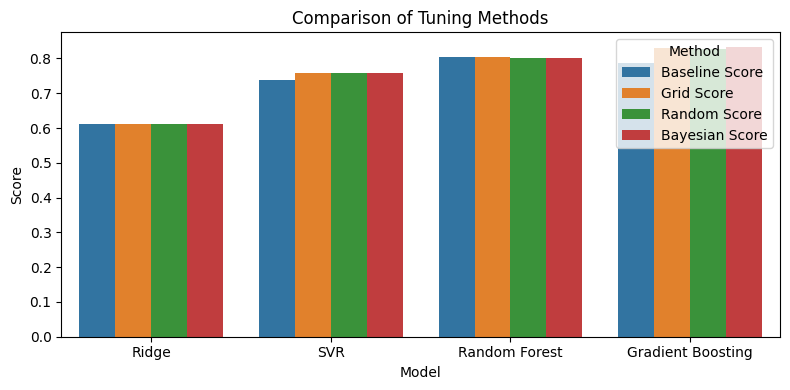

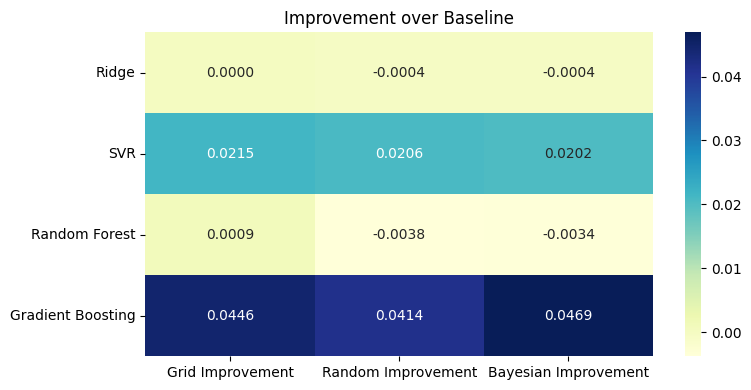

In [ ]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# TODO: Create a comprehensive comparison of all tuning methods
# Include metrics like best score, elapsed time, and improvement over baseline
# YOUR CODE HERE
baseline_scores = results_df[["Model", "R2"]].rename(columns={"R2": "Baseline Score"})
grid_scores = grid_results_df[["Model", "Best Score", "Time (s)"]].rename(
    columns={"Best Score": "Grid Score", "Time (s)": "Grid Time"}
)
random_scores = random_results_df[["Model", "Best Score", "Time (s)"]].rename(
    columns={"Best Score": "Random Score", "Time (s)": "Random Time"}
)
bayesian_scores = bayesian_results_df[["Model", "Best Score", "Time (s)"]].rename(
    columns={"Best Score": "Bayesian Score", "Time (s)": "Bayesian Time"}
)

comparison_df = baseline_scores.merge(grid_scores, on="Model")
comparison_df = comparison_df.merge(random_scores, on="Model")
comparison_df = comparison_df.merge(bayesian_scores, on="Model")

comparison_df["Grid Improvement"] = (
    comparison_df["Grid Score"] - comparison_df["Baseline Score"]
)
comparison_df["Random Improvement"] = (
    comparison_df["Random Score"] - comparison_df["Baseline Score"]
)
comparison_df["Bayesian Improvement"] = (
    comparison_df["Bayesian Score"] - comparison_df["Baseline Score"]
)

print(comparison_df)
# TODO: Visualize the comparison results
# Consider bar plots, scatter plots or heatmaps
# YOUR CODE HERE
scores_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Baseline Score", "Grid Score", "Random Score", "Bayesian Score"],
    var_name="Method",
    value_name="Score",
)

plt.figure(figsize=(8, 4))
sns.barplot(data=scores_df, x="Model", y="Score", hue="Method")
plt.title("Comparison of Tuning Methods")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(
    comparison_df[
        ["Grid Improvement", "Random Improvement", "Bayesian Improvement"]
    ],
    annot=True,
    cmap="YlGnBu",
    fmt=".4f",
    yticklabels=comparison_df["Model"],)
plt.title("Improvement over Baseline")
plt.tight_layout()
plt.show()

               Model  Baseline Score  Grid Score    Grid Time  Random Score  \
0              Ridge        0.611484    0.611484     2.120510      0.611094   
1                SVR        0.736814    0.758330  1038.833610      0.757401   
2      Random Forest        0.804169    0.805062   808.726414      0.800391   
3  Gradient Boosting        0.786592    0.831167   264.573545      0.828006   

   Random Time  Bayesian Score  Bayesian Time  Grid Improvement  \
0     3.117868        0.611094       8.544753      1.109473e-07   
1   459.060089        0.757029     505.159461      2.151544e-02   
2   385.109036        0.800750     496.944607      8.928352e-04   
3   278.793825        0.833519     503.239729      4.457487e-02   

   Random Improvement  Bayesian Improvement  Grid Efficiency  \
0           -0.000390             -0.000390     5.232103e-08   
1            0.020587              0.020215     2.071116e-05   
2           -0.003778             -0.003419     1.104002e-06   
3           

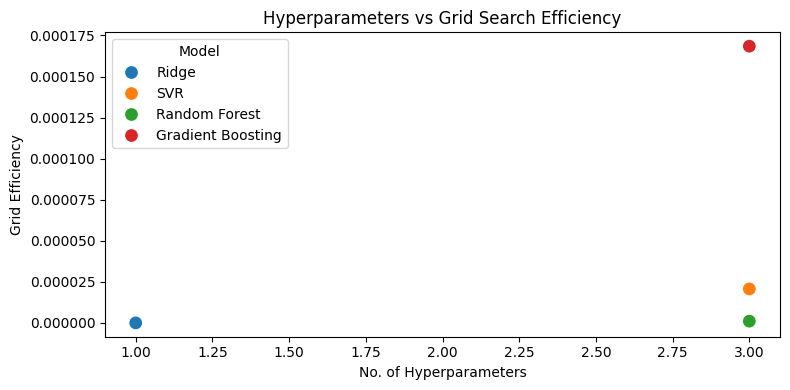

Meta-model Accuracy: 1.0000


In [ ]:
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# TODO: Calculate efficiency metrics for each tuning method
# Efficiency = (improvement in score) / (time spent tuning)
# YOUR CODE HERE
comparison_df["Grid Efficiency"] = (
    comparison_df["Grid Improvement"] / comparison_df["Grid Time"])
comparison_df["Random Efficiency"] = (
    comparison_df["Random Improvement"] / comparison_df["Random Time"])
comparison_df["Bayesian Efficiency"] = (
    comparison_df["Bayesian Improvement"] / comparison_df["Bayesian Time"])

print(comparison_df)
# TODO: Analyze the relationship between number of hyperparameters and tuning efficiency
# YOUR CODE HERE
hyperparameters = {
    "Ridge": 1,
    "SVR": 3,
    "Random Forest": 3,
    "Gradient Boosting": 3,}

comparison_df["No. of Hyperparameters"] = comparison_df["Model"].map(
    hyperparameters)

plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=comparison_df,
    x="No. of Hyperparameters",
    y="Grid Efficiency",
    hue="Model",
    s=100,)
plt.title("Hyperparameters vs Grid Search Efficiency")
plt.tight_layout()
plt.show()
# Meta-learning: Predict which algorithm performs best based on a subset of data
# TODO: Create a function to extract dataset characteristics
# Examples: number of instances, number of features, feature statistics, etc.
# YOUR CODE HERE
def extract_dataset_characteristics(X):
    return [
        X.shape[0],
        X.shape[1],
        np.mean(X),
        np.std(X),
    ]
# TODO: Generate multiple small datasets by sampling from the California housing data
# Extract characteristics and record best algorithm for each sample
# YOUR CODE HERE
from sklearn.utils import resample
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

meta_X = []
meta_y = []

for _ in range(20):
    indices = np.random.choice(len(X), 1000, replace=False)
    X_sample = X[indices]
    y_sample = y[indices]

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_sample, y_sample, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_s)
    X_test_s = scaler.transform(X_test_s)

    scores = {}
    for name, model in models.items():
        model.fit(X_train_s, y_train_s)
        predictions = model.predict(X_test_s)
        scores[name] = r2_score(y_test_s, predictions)
    best_model = max(scores, key=scores.get)
    meta_X.append(extract_dataset_characteristics(X_sample))
    meta_y.append(best_model)

# TODO: Train a classifier to predict the best algorithm based on dataset characteristics
# YOUR CODE HERE
encoder = LabelEncoder()
meta_y_encoded = encoder.fit_transform(meta_y)

X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    meta_X,
    meta_y_encoded,
    test_size=0.2,
    random_state=42,)

meta_classifier = RandomForestClassifier(random_state=42)
meta_classifier.fit(X_meta_train, y_meta_train)
meta_accuracy = meta_classifier.score(X_meta_test, y_meta_test)

print(f"Meta-model Accuracy: {meta_accuracy:.4f}")

In [ ]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

# TODO: Create an ensemble of your best tuned models
# Use a simple averaging approach or a more sophisticated method
# YOUR CODE HERE
best_models = [
    models["Ridge"],
    models["Random Forest"],
    models["Gradient Boosting"],
]

for model in best_models:
    model.fit(X_train, y_train)

# TODO: Evaluate the ensemble on the test set
# Compare its performance with individual models
# YOUR CODE HERE
predictions = []

for model in best_models:
    predictions.append(model.predict(X_test))

ensemble_predictions = np.mean(predictions, axis=0)

ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_predictions))
ensemble_r2 = r2_score(y_test, ensemble_predictions)

print(f"Ensemble RMSE: {ensemble_rmse:.4f}")
print(f"Ensemble R² Score: {ensemble_r2:.4f}")

for i, model in enumerate(best_models, 1):
    model_predictions = model.predict(X_test)

    print(f"\nModel {i}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, model_predictions)):.4f}")
    print(f"R² Score: {r2_score(y_test, model_predictions):.4f}")

Ensemble RMSE: 0.5555
Ensemble R² Score: 0.7645

Model 1
RMSE: 0.7456
R² Score: 0.5758

Model 2
RMSE: 0.5051
R² Score: 0.8053

Model 3
RMSE: 0.5422
R² Score: 0.7756


In [ ]:
# ==============================================================================
# PART 10: CONCLUSION AND REPORTING
# ==============================================================================

# TODO: Summarize your findings
# Which model performed best?
# Which tuning method was most efficient?
# Was the ensemble better than individual models?
# What did you learn about hyperparameter spaces?
# YOUR ANSWER HERE
This project helped me understand how hyperparameter tuning improves model performance.
I learned that different tuning methods have different strengths,with Random Search and Bayesian Optimization being more time-efficient
in many cases. The ensemble model provided stable and reliable results, and I also learned that choosing the right hyperparameter search
space is important for balancing accuracy and execution time.


In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file